In [1]:
import logging
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import scarf
from scarf import cytebase
from scarf.plotting import CellField, NormalizationSpec

scarf.configure_output(level="WARNING", progress=False)
# HF retry messages include private bucket URLs; keep them out of shared outputs.
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
catalog = cytebase.Catalog()  # Public Cytebase unless CYTEBASE_BUCKET is set.

In [2]:
ready = catalog.find_datasets(ready_only=True)
ready

| Cytebase ID | Status | Cells | Genes | Tissues | Diseases |
| --- | --- | ---: | ---: | --- | --- |
| tabula&#95;2022&#95;tabula&#95;sapiens&#95;all&#95;cells&#95;53d208b0 | ready | 1,136,218 | 60,606 | abdominal aorta, adipose tissue, anterior part of tongue, anterior segment of eyeball, aorta, ascen… | normal |
| garridotrigo&#95;2023&#95;ibd&#95;hc&#95;10x&#95;single&#95;cell&#95;transcriptomics&#95;data&#95;9bfecd44 | ready | 46,700 | 32,354 | mucosa of ascending colon, mucosa of descending colon, mucosa of rectum, mucosa of sigmoid colon, m… | Crohn disease, normal, ulcerative colitis |
| wilk&#95;2020&#95;single&#95;cell&#95;atlas&#95;peripheral&#95;sars&#95;cov&#95;2&#95;infection&#95;456e8b9b | ready | 44,721 | 24,505 | blood | COVID-19, normal |
| soleboldo&#95;2020&#95;single&#95;cell&#95;loss&#95;fibroblast&#95;priming&#95;124744b8 | ready | 15,457 | 30,172 | zone of skin | normal |

4 rows. Long cells are shortened; use `max_cell_chars=None` to display complete values. Row dictionaries retain the full values.

In [3]:
matches = catalog.search("soleboldo", ready_only=True, max_cell_chars=None)
if not matches:
    raise RuntimeError("The example skin dataset is not ready in this bucket")
matches

| Cytebase ID | Title | Cells | Tissues | Diseases |
| --- | --- | ---: | --- | --- |
| soleboldo&#95;2020&#95;single&#95;cell&#95;loss&#95;fibroblast&#95;priming&#95;124744b8 | Single-cell transcriptomes of the human skin reveal age-related loss of fibroblast priming | 15,457 | zone of skin | normal |

1 row.

In [4]:
dataset_id = matches[0]["cytebase_id"]
dataset = catalog.dataset(dataset_id)
dataset

### Single-cell transcriptomes of the human skin reveal age-related loss of fibroblast priming

- **Cytebase ID:** `soleboldo_2020_single_cell_loss_fibroblast_priming_124744b8`
- **Citation:**
    - Publication: https://doi.org/10.1038/s42003-020-0922-4
    - Dataset Version: https://datasets.cellxgene.cziscience.com/1a6bbe2b-4eed-477a-97c9-f7a74d4874d7.h5ad
    - curated and distributed by CZ CELLxGENE Discover in Collection: https://cellxgene.cziscience.com/collections/c353707f-09a4-4f12-92a0-cb741e57e5f0
- **DOI:** 10.1038/s42003-020-0922-4
- **CELLxGENE:** https://cellxgene.cziscience.com/collections/c353707f-09a4-4f12-92a0-cb741e57e5f0
- **Explorer:** https://cellxgene.cziscience.com/e/124744b8-4681-474a-9894-683896122708.cxg/
- **Size:** 15,457 cells, 30,172 genes
- **Status:** ready
- **Organisms:** Homo sapiens
- **Assays:** 10x 3' v2
- **Tissues:** zone of skin
- **Diseases:** normal
- **Suspension:** cell
- **Source embeddings:** X_pca, X_umap

In [5]:
catalog.list_terms("disease")

| Label | Ontology ID | Datasets |
| --- | --- | ---: |
| COVID-19 | MONDO:0100096 | 1 |
| Crohn disease | MONDO:0005011 | 1 |
| normal | PATO:0000461 | 4 |
| ulcerative colitis | MONDO:0005101 | 1 |

4 rows.

In [6]:
tissue = matches[0]["tissue_labels"][0]
catalog.find_datasets(tissue=tissue, organism="Homo sapiens", ready_only=True)

| Cytebase ID | Status | Cells | Genes | Tissues | Diseases |
| --- | --- | ---: | ---: | --- | --- |
| soleboldo&#95;2020&#95;single&#95;cell&#95;loss&#95;fibroblast&#95;priming&#95;124744b8 | ready | 15,457 | 30,172 | zone of skin | normal |

1 row.

In [7]:
catalog.query(
    """
    SELECT cytebase_id, first_author, year, cell_count, n_genes,
           len(cell_type_labels) AS n_cell_types
    FROM datasets
    WHERE status = ? AND processed_version_id = latest_version_id
      AND zarr_uri IS NOT NULL
    ORDER BY cell_count
    LIMIT 10
    """,
    parameters=["ready"],
)

| Cytebase ID | First Author | Year | Cells | Genes | N Cell Types |
| --- | --- | ---: | ---: | ---: | --- |
| soleboldo&#95;2020&#95;single&#95;cell&#95;loss&#95;fibroblast&#95;priming&#95;124744b8 | Solé-Boldo | 2,020 | 15,457 | 30,172 | 10 |
| wilk&#95;2020&#95;single&#95;cell&#95;atlas&#95;peripheral&#95;sars&#95;cov&#95;2&#95;infection&#95;456e8b9b | Wilk | 2,020 | 44,721 | 24,505 | 19 |
| garridotrigo&#95;2023&#95;ibd&#95;hc&#95;10x&#95;single&#95;cell&#95;transcriptomics&#95;data&#95;9bfecd44 | Garrido-Trigo | 2,023 | 46,700 | 32,354 | 5 |
| tabula&#95;2022&#95;tabula&#95;sapiens&#95;all&#95;cells&#95;53d208b0 | The Tabula Sapiens Consortium&#42; | 2,022 | 1,136,218 | 60,606 | 180 |

4 rows.

In [8]:
ds = dataset.open()
ds

DataStore has 15457 (15457) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'Celltype', 'Cluster', 
            'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 'RNA_percentRibo', 'age', 
            'alignment_software', 'assay', 'assay_ontology_term_id', 'cell_enrichment', 'cell_type', 
            'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 
            'donor_id', 'gene_annotation_version', 'institute', 'is_primary_data', 'library_id', 
            'library_preparation_batch', 'library_sequencing_run', 'manner_of_death', 'observation_joinid', 'reference_genome', 
            'sample_collection_method', 'sample_id', 'sample_preservation_method', 'sample_source', 'sampled_site_condition', 
            'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sequenced_fragment', 'sex', 'sex_ontology_term_id', 
            'suspension_type', 'tissue', 'tissue

In [9]:
print("Source embedding keys:", dataset.source_embeddings())
print("Imported embedding keys:", sorted(dataset.embeddings()))

Source embedding keys: ['X_pca', 'X_umap']


Imported embedding keys: ['X_umap']


In [10]:
wanted = ["cell_type", "tissue", "disease", "donor_id", "sex", "assay"]
columns = [column for column in wanted if column in ds.cells.columns]
meta = dataset.cell_metadata(["ids", *columns]).set_index("ids")
meta.head()

,cell_type,tissue,disease,donor_id,sex,assay
ids,,,,,,
AAACCTGAGTTAAGTG-1,T cell,zone of skin,normal,S1,male,10x 3' v2
AAACCTGTCCATTCTA-1,T cell,zone of skin,normal,S1,male,10x 3' v2
AACACGTGTTCCACAA-1,T cell,zone of skin,normal,S1,male,10x 3' v2
AACCGCGCACGCGAAA-1,T cell,zone of skin,normal,S1,male,10x 3' v2
AACCGCGCACTGAAGG-1,T cell,zone of skin,normal,S1,male,10x 3' v2


In [11]:
meta["cell_type"].value_counts().rename("cells").to_frame()

,cells
cell_type,
skin fibroblast,5948
macrophage,2228
endothelial cell of vascular tree,1467
keratinocyte,1399
T cell,1281
pericyte,1220
stem cell of epidermis,1187
erythrocyte,310
endothelial cell of lymphatic vessel,294


In [12]:
if "donor_id" in meta:
    display(pd.crosstab(meta["cell_type"], meta["donor_id"]))

donor_id,S1,S2,S3,S4,S5
cell_type,,,,,
T cell,602,452,80,21,126
endothelial cell of lymphatic vessel,39,26,101,48,80
endothelial cell of vascular tree,144,293,510,198,322
erythrocyte,1,271,14,16,8
keratinocyte,73,57,351,580,338
macrophage,495,185,483,194,871
melanocyte,16,18,46,17,26
pericyte,374,434,221,75,116
skin fibroblast,903,889,1185,591,2380


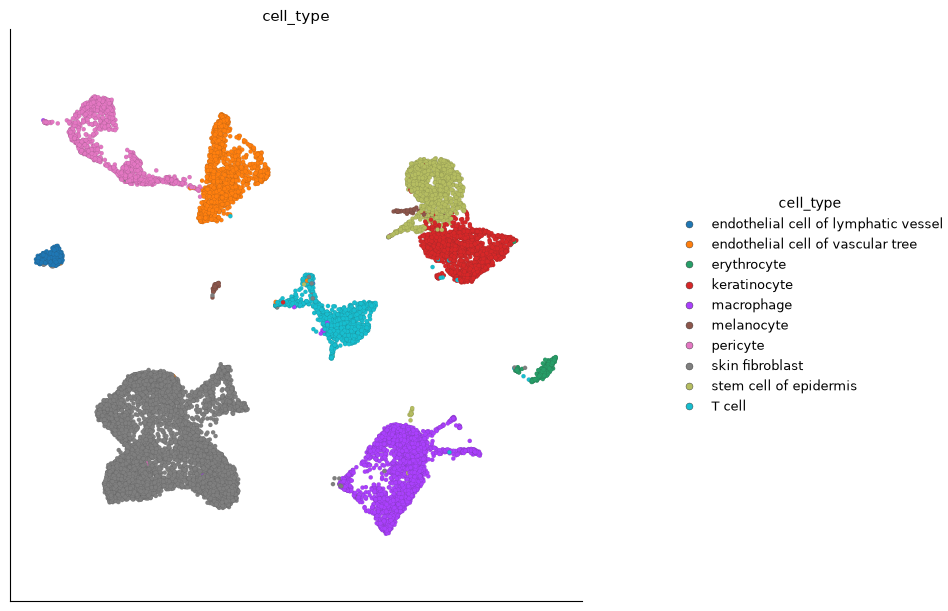

In [13]:
cell_type_plot = dataset.plot_embedding(color_by="cell_type", figsize=(10, 6))

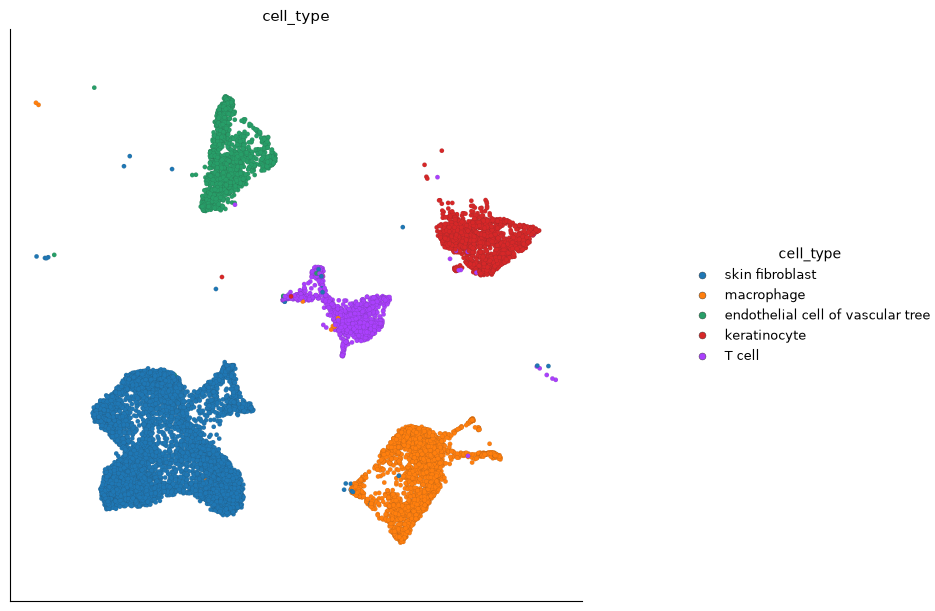

In [14]:
top_types = meta["cell_type"].value_counts().head(5).index.tolist()
dataset.plot_embedding(
    color_by="cell_type", groups=top_types, figsize=(10, 6)
);

In [15]:
requested_genes = ["PTPRC", "EPCAM", "COL1A1", "PECAM1"]
by_upper = {str(name).upper(): str(name) for name in ds.RNA.feats.fetch_all("names")}
genes = [by_upper[name.upper()] for name in requested_genes if name.upper() in by_upper]
print("Found:", genes)
print("Missing:", [name for name in requested_genes if name.upper() not in by_upper])

Found: ['PTPRC', 'EPCAM', 'COL1A1']
Missing: ['PECAM1']


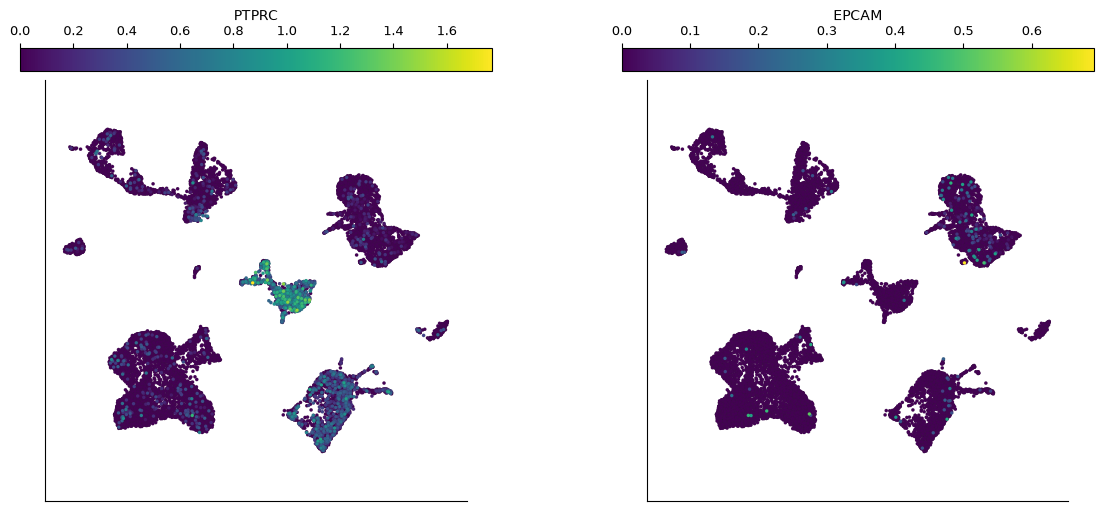

In [16]:
if genes:
    dataset.plot_embedding(
        color_by=genes[:2],
        normalization=NormalizationSpec(transform="log1p"),
        sort_values=True,
        n_columns=2,
        figsize=(12, 5),
    );

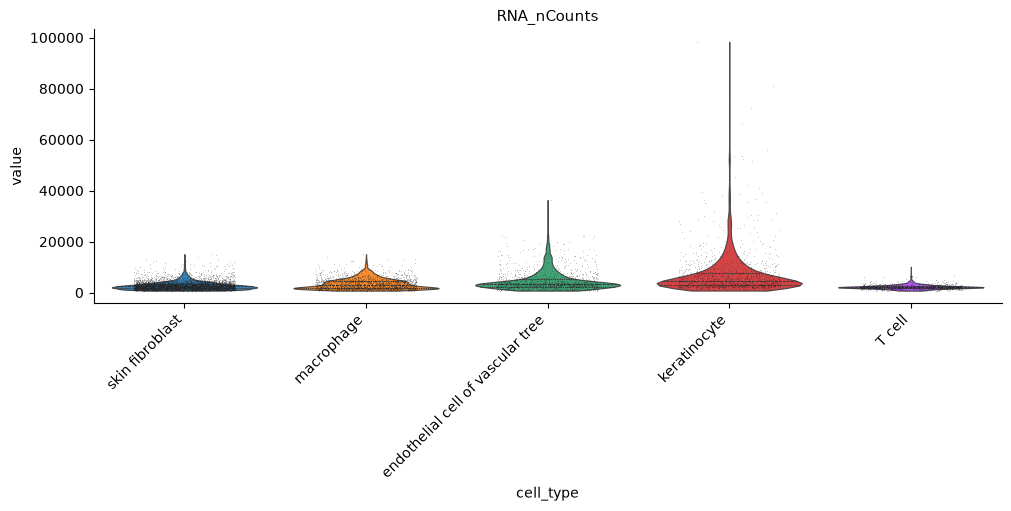

In [17]:
if "RNA_nCounts" in ds.cells.columns:
    ds.plots.distribution(
        "RNA_nCounts",
        grouping=CellField("cell_type"),
        groups=top_types,
        figsize=(10, 5),
    );

In [18]:
coords = dataset.embedding_coordinates()
frame = coords.join(meta)
frame.head()

,umap_1,umap_2,cell_type,tissue,disease,donor_id,sex,assay
ids,,,,,,,,
AAACCTGAGTTAAGTG-1,1.208051,2.397442,T cell,zone of skin,normal,S1,male,10x 3' v2
AAACCTGTCCATTCTA-1,3.684427,0.795145,T cell,zone of skin,normal,S1,male,10x 3' v2
AACACGTGTTCCACAA-1,1.241455,2.388342,T cell,zone of skin,normal,S1,male,10x 3' v2
AACCGCGCACGCGAAA-1,4.937868,2.031314,T cell,zone of skin,normal,S1,male,10x 3' v2
AACCGCGCACTGAAGG-1,1.217588,2.472315,T cell,zone of skin,normal,S1,male,10x 3' v2


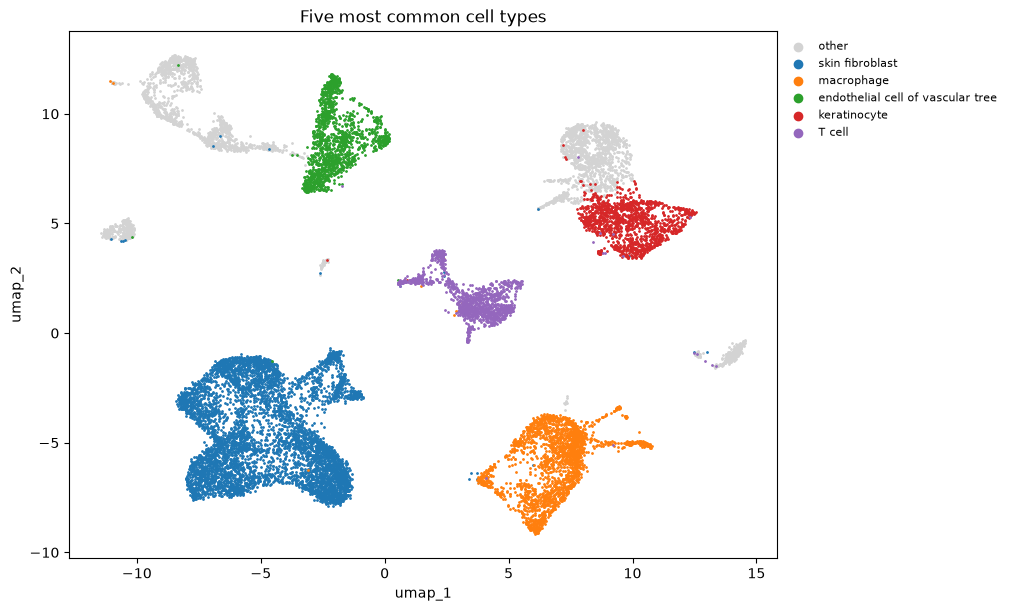

In [19]:
x, y = coords.columns[:2]
top = frame["cell_type"].value_counts().head(5).index
rest = frame[~frame["cell_type"].isin(top)]

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
ax.scatter(rest[x], rest[y], s=1, c="lightgrey", label="other", rasterized=True)
for label in top:
    part = frame[frame["cell_type"] == label]
    ax.scatter(part[x], part[y], s=1, label=label, rasterized=True)
ax.set(xlabel=x, ylabel=y, title="Five most common cell types")
ax.legend(
    markerscale=6, fontsize=8, bbox_to_anchor=(1, 1), loc="upper left", frameon=False
)
plt.show()
plt.close(fig)

In [20]:
out = Path("figures")
out.mkdir(exist_ok=True)
cell_type_plot.save(out / "cytebase_cell_types.png", dpi=150)
cell_type_plot.close()
print("Saved figures/cytebase_cell_types.png")

Saved figures/cytebase_cell_types.png
